# ML4SCI Task 6: Multi-Model Strong-Lensing Super-Resolution

This notebook presents a PyTorch super-resolution study for **DeepLense Task VI.A** with an optional **Task VI.B** fine-tuning stage. The primary objective is to reconstruct high-resolution simulated strong-lensing images from paired low-resolution inputs using three model families: **SRResNet**, **RCAN**, and **SwinIR**, then optionally transfer those learned weights to the real HSC/HST telescope pairs.

The experimental pipeline combines explicit LR-HR pairing, intensity normalization, train-time geometric augmentation, RAM-side dataset caching, mixed-precision training, checkpoint saving, and evaluation with **MSE**, **PSNR**, **SSIM**, and qualitative reconstruction panels. To keep execution stable on Windows, dataset construction, dataloader creation, and model training are deferred to the final `if __name__ == "__main__":` block.

## Notebook Structure

The notebook is organized as a compact experimental workflow:

1. define the experimental configuration and shared constants
2. define data-loading, preprocessing, augmentation, and caching utilities
3. define model-building, optimization, training, and evaluation utilities
4. execute the full comparison across multiple super-resolution backbones for Task VI.A
5. optionally cascade the best Task VI.A weights into Task VI.B for domain adaptation on real telescope data

## Methodological Strategy

The task is approached as a **scientific image reconstruction** problem rather than a generic computer-vision benchmark. The main assumptions guiding the design are:

- paired simulated LR-HR images provide direct supervision for controlled model comparison in Task VI.A
- residual and attention-based CNNs offer strong local priors for recovering lensing structure
- a compact SwinIR baseline tests whether global context modeling improves reconstruction quality under the same pipeline
- geometric augmentation should reflect orientation variability while preserving astrophysical content
- reconstruction quality should be judged with **MSE**, **PSNR**, **SSIM**, and direct visual inspection of predicted images
- Task VI.B should begin from the best Task VI.A weights with a reduced learning rate rather than training from scratch

This combination is intended to preserve scientifically meaningful morphology while remaining practical to train on a local machine.

## Data and Preprocessing Setup

The following code establishes the shared experimental environment: imports, configuration, dataset indexing, tensor preprocessing, augmentation, RAM-side caching, and preview logic. This section forms the input pipeline used by every model in the comparison, so keeping it centralized ensures that architectural differences are evaluated under the same data conditions.

In [1]:
import math
import os
import random
import sys
import urllib.request
import warnings
from dataclasses import dataclass
from pathlib import Path

from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning, module="torch.functional")
warnings.filterwarnings("ignore", category=FutureWarning, module="timm.models.layers")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset


### `Config`: Experimental Configuration
This cell defines the global experiment configuration, including dataset locations, training schedule, AMP defaults, output/checkpoint locations, and per-model experiment metadata. Keeping these values together makes the notebook easier to reproduce and ensures that model comparisons are driven by controlled changes rather than hidden defaults.

In [2]:
def resolve_task6_dir() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, cwd / "Task-6"]
    for candidate in candidates:
        if (candidate / "Dataset_A").exists() or (candidate / "dataset_a").exists():
            return candidate
    return cwd


@dataclass
class Config:
    task_dir: Path = resolve_task6_dir()
    dataset_a_dir: Path = resolve_task6_dir() / "Dataset_A"
    dataset_b_dir: Path = resolve_task6_dir() / "Dataset_B"
    output_dir: Path = resolve_task6_dir()
    seed: int = 42
    train_ratio: float = 0.9
    num_workers: int = 0
    epochs_a: int = 10
    epochs_b: int = 5
    use_augmentation: bool = True
    use_dataset_b_finetune: bool = True
    image_extensions: tuple = (".npy", ".png", ".jpg", ".jpeg", ".tif", ".tiff")
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()
CFG.output_dir.mkdir(parents=True, exist_ok=True)

experiment_settings = {
    "srresnet": {
        "display_name": "SRResNet",
        "batch_size": 8,
        "lr": 1e-4,
        "weight_decay": 1e-5,
    },
    "rcan": {
        "display_name": "RCAN",
        "batch_size": 8,
        "lr": 1e-4,
        "weight_decay": 1e-5,
    },
    "swinir": {
        "display_name": "SwinIR",
        "batch_size": 4,
        "lr": 2e-4,
        "weight_decay": 1e-4,
    },
}

### `set_seed`: Reproducibility Control
This helper fixes the random state for Python, NumPy, and PyTorch. Its purpose is to reduce run-to-run variance so that observed differences between architectures are more likely to reflect the models themselves rather than stochastic effects.

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)


### `SwinIR` Setup: External Architecture Import
This cell resolves the SwinIR dependency by downloading the official architecture file if it is not already present locally. Keeping the external-model setup isolated makes the notebook easier to read while preserving a reproducible way to include the Transformer baseline.

In [4]:
SWINIR_PATH = CFG.task_dir / "network_swinir.py"
if not SWINIR_PATH.exists():
    print("Downloading official SwinIR architecture...")
    url = "https://raw.githubusercontent.com/JingyunLiang/SwinIR/main/models/network_swinir.py"
    urllib.request.urlretrieve(url, SWINIR_PATH)

if str(CFG.task_dir) not in sys.path:
    sys.path.insert(0, str(CFG.task_dir))

from network_swinir import SwinIR


### `find_split_dirs`: Robust LR-HR Directory Discovery
This helper locates the matching `LR` and `HR` folders for Task VI.A. It allows the notebook to work even when intermediate folder names vary, provided that the paired low-resolution and high-resolution directories share the same parent.

In [5]:
def find_split_dirs(root_dir: Path) -> tuple[Path, Path]:
    if not root_dir.exists():
        raise FileNotFoundError(f"Missing dataset root: {root_dir}")

    direct_lr, direct_hr = root_dir / "LR", root_dir / "HR"
    if direct_lr.exists() and direct_hr.exists():
        return direct_lr, direct_hr

    lr_dirs = sorted([p for p in root_dir.rglob("LR") if p.is_dir()])
    hr_dirs = sorted([p for p in root_dir.rglob("HR") if p.is_dir()])
    for lr_dir in lr_dirs:
        lr_parent = lr_dir.parent.resolve()
        for hr_dir in hr_dirs:
            if hr_dir.parent.resolve() == lr_parent:
                return lr_dir, hr_dir

    raise FileNotFoundError(f"Could not find matching LR/HR folders under {root_dir}")


### `collect_records`: Paired Dataset Index Construction
This function scans the discovered `LR` and `HR` folders and converts them into a dataframe of aligned file pairs. It serves as the structured representation of the dataset used throughout the rest of the notebook.

In [6]:
def collect_records(root_dir: Path, split_name: str) -> pd.DataFrame:
    lr_dir, hr_dir = find_split_dirs(root_dir)

    def canonical_pair_id(path: Path, base_dir: Path) -> str:
        relative = path.relative_to(base_dir).with_suffix("")
        stem = relative.name
        stem_lower = stem.lower()

        prefixed_variants = ("lr_", "hr_", "lr-", "hr-")
        matched_prefix = next((prefix for prefix in prefixed_variants if stem_lower.startswith(prefix)), None)
        if matched_prefix is not None:
            stem = stem[len(matched_prefix):]
        elif len(stem) > 2 and stem_lower[:2] in {"lr", "hr"} and stem[2].isdigit():
            stem = stem[2:]

        suffix_variants = ("_lr", "_hr", "-lr", "-hr")
        stem_lower = stem.lower()
        matched_suffix = next((suffix for suffix in suffix_variants if stem_lower.endswith(suffix)), None)
        if matched_suffix is not None:
            stem = stem[:-len(matched_suffix)]

        parent = relative.parent.as_posix()
        canonical = stem.lower()
        if parent != ".":
            canonical = f"{parent.lower()}/{canonical}"
        return canonical

    def index_dir(base_dir: Path):
        return {
            canonical_pair_id(path, base_dir): path
            for path in sorted(base_dir.rglob("*"))
            if path.is_file() and path.suffix.lower() in CFG.image_extensions
        }

    lr_index = index_dir(lr_dir)
    hr_index = index_dir(hr_dir)
    common_keys = sorted(set(lr_index) & set(hr_index))
    records = [
        {
            "pair_id": key,
            "split": split_name,
            "lr_path": str(lr_index[key]),
            "hr_path": str(hr_index[key]),
        }
        for key in common_keys
    ]
    dataframe = pd.DataFrame(records)
    print(f"{split_name}: found {len(dataframe)} paired samples")
    if dataframe.empty:
        print(f"{split_name}: no matched LR/HR pairs were found under {root_dir}.")
    return dataframe


### `load_array`: File Loading and Shape Normalization
This helper loads either `.npy` or image files and normalizes their dimensional structure into a consistent grayscale array representation. Its role is to absorb file-format differences before any scientific preprocessing is applied.

In [7]:
def load_array(path: Path) -> np.ndarray:
    if path.suffix.lower() == ".npy":
        array = np.load(path)
    else:
        array = np.asarray(plt.imread(path))

    if array.ndim == 0:
        array = array.reshape(1, 1)
    elif array.ndim == 1:
        side = int(round(math.sqrt(array.size)))
        array = array.reshape(side, side) if side * side == array.size else array.reshape(1, -1)
    elif array.ndim == 3:
        if array.shape[0] == 1:
            array = array[0]
        elif array.shape[-1] == 1:
            array = array[..., 0]
        else:
            array = array[..., 0]
    elif array.ndim > 3:
        array = np.squeeze(array)
        while array.ndim > 2:
            array = array[0]

    return array.astype(np.float32)


### `preprocess_sample`: Physical Signal Preparation
This is the core preprocessing routine for a single lensing map. It applies numerical cleanup, rescales the intensity range, and converts the sample into a single-channel tensor so every model sees a standardized input representation.

In [8]:
def preprocess_sample(sample: np.ndarray) -> torch.Tensor:
    sample = np.nan_to_num(sample, nan=0.0, posinf=0.0, neginf=0.0)
    sample = sample - sample.min()
    sample = sample / (sample.max() + 1e-8)
    tensor = torch.tensor(sample, dtype=torch.float32)
    if tensor.ndim in [1, 2]:
        tensor = tensor.unsqueeze(0)
    return tensor


### `PairedSuperResolutionDataset`: Sample Loading Interface
This dataset class is the unified loader for Task VI.A. It preloads paired LR-HR tensors into RAM, applies optional augmentation during training, and acts as the main interface between the indexed dataframe and the PyTorch training loop.

In [9]:
class PairedSuperResolutionDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, split: str = "eval", augment: bool = False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.split = split
        self.augment = augment

        print(f"Pre-loading {split} dataset into RAM... ", end="")
        self.cache = []
        for index in range(len(self.dataframe)):
            row = self.dataframe.iloc[index]
            lr = preprocess_sample(load_array(Path(row["lr_path"])))
            hr = preprocess_sample(load_array(Path(row["hr_path"])))
            self.cache.append((lr, hr, row["pair_id"]))
        print("Done!")

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        lr, hr, pair_id = self.cache[index]
        lr = lr.clone()
        hr = hr.clone()

        if self.augment and self.split == "train":
            if random.random() > 0.5:
                lr = torch.flip(lr, dims=[-1])
                hr = torch.flip(hr, dims=[-1])
            if random.random() > 0.5:
                lr = torch.flip(lr, dims=[-2])
                hr = torch.flip(hr, dims=[-2])
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                lr = torch.rot90(lr, k=k, dims=[-2, -1])
                hr = torch.rot90(hr, k=k, dims=[-2, -1])

        return lr, hr, pair_id


### `preview_dataset`: Sanity Check Visualization
This helper reports the sample count, tensor shapes, and one representative LR-HR pair. It is used as a quick validation step before training to confirm that pairing and preprocessing are working as expected.

In [10]:
def preview_dataset(dataframe: pd.DataFrame, title: str) -> None:
    print("Samples:", len(dataframe))
    if dataframe.empty:
        return

    dataset = PairedSuperResolutionDataset(dataframe.head(1))
    lr, hr, pair_id = dataset[0]
    print("Pair:", pair_id)
    print("LR shape:", tuple(lr.shape), "HR shape:", tuple(hr.shape))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(lr[0].numpy(), cmap="magma", aspect="auto")
    axes[0].set_title(f"{title}: LR")
    axes[1].imshow(hr[0].numpy(), cmap="magma", aspect="auto")
    axes[1].set_title(f"{title}: HR")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Model Definitions and Training Utilities

This section defines the shared model-building and training components used across experiments. The notebook compares multiple super-resolution backbones under a common optimization and evaluation pipeline so that architectural differences can be interpreted more cleanly.

## Evaluation Design

The evaluation code is designed to answer two related questions:

- **How accurately does each model reconstruct the high-resolution target?**
- **How well does each architecture preserve perceptual and structural lensing information?**

For that reason, the notebook records training loss, validation MSE, PSNR, SSIM, saved checkpoints, and qualitative reconstruction panels. This is especially important for lensing applications, where preserving faint arcs and ring morphology matters as much as minimizing average pixel error.

### `UpsampleBlock`, `ResidualBlock`, and `SRResNet`: Residual Convolutional Baseline
These building blocks define the residual CNN baseline. They provide a strong local reconstruction prior and establish a clean point of comparison for the more expressive attention-based models.

In [11]:
class UpsampleBlock(nn.Module):
    def __init__(self, channels: int, scale: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels * (scale ** 2), kernel_size=3, padding=1),
            nn.PixelShuffle(scale),
            nn.PReLU(),
        )

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class SRResNet(nn.Module):
    def __init__(self, upscale_factor: int, channels: int = 64, num_res_blocks: int = 8):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(1, channels, 9, 1, 4), nn.PReLU())
        self.body = nn.Sequential(*[ResidualBlock(channels) for _ in range(num_res_blocks)])
        self.body_tail = nn.Sequential(nn.Conv2d(channels, channels, 3, 1, 1), nn.BatchNorm2d(channels))

        if upscale_factor in {2, 4, 8}:
            up_blocks = [UpsampleBlock(channels, 2) for _ in range(int(math.log2(upscale_factor)))]
        elif upscale_factor == 3:
            up_blocks = [UpsampleBlock(channels, 3)]
        else:
            up_blocks = []
        self.upsampler = nn.Sequential(*up_blocks) if up_blocks else nn.Identity()
        self.tail = nn.Conv2d(channels, 1, 9, 1, 4)

    def forward(self, x):
        residual = self.head(x)
        features = self.body_tail(self.body(residual)) + residual
        return self.tail(self.upsampler(features))


### `ChannelAttention`, `RCAB`, and `LensingRCAN`: Attention-Based CNN
This section defines the RCAN-style architecture used in the comparison. Channel attention is introduced to help the model emphasize informative feature responses while suppressing less useful activations during reconstruction.

In [12]:
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Sequential(
            nn.Conv2d(channels, reduced, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced, channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.conv(self.pool(x))


class RCAB(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1),
            ChannelAttention(channels),
        )

    def forward(self, x):
        return x + self.body(x)


class LensingRCAN(nn.Module):
    def __init__(self, upscale_factor: int, channels: int = 64, num_blocks: int = 8):
        super().__init__()
        self.head = nn.Conv2d(1, channels, 3, 1, 1)
        self.body = nn.Sequential(*[RCAB(channels) for _ in range(num_blocks)], nn.Conv2d(channels, channels, 3, 1, 1))

        if upscale_factor in {2, 4, 8}:
            up_blocks = [UpsampleBlock(channels, 2) for _ in range(int(math.log2(upscale_factor)))]
        elif upscale_factor == 3:
            up_blocks = [UpsampleBlock(channels, 3)]
        else:
            up_blocks = []
        self.upsampler = nn.Sequential(*up_blocks) if up_blocks else nn.Identity()
        self.tail = nn.Conv2d(channels, 1, 3, 1, 1)

    def forward(self, x):
        residual = self.head(x)
        features = self.body(residual) + residual
        return self.tail(self.upsampler(features))


### `infer_upscale_factor` and `build_model`: Backbone Factory
These helpers infer the LR-to-HR scaling factor directly from the dataset and construct the requested model architecture. Centralizing the model factory keeps the rest of the notebook independent of backbone-specific details.

In [13]:
def infer_upscale_factor(dataframe: pd.DataFrame) -> int:
    row = dataframe.iloc[0]
    lr = preprocess_sample(load_array(Path(row["lr_path"])))
    hr = preprocess_sample(load_array(Path(row["hr_path"])))
    lr_h, lr_w = lr.shape[-2:]
    hr_h, hr_w = hr.shape[-2:]
    if hr_h % lr_h != 0 or hr_w % lr_w != 0:
        raise ValueError(f"Non-integer scale ratio: LR {(lr_h, lr_w)} vs HR {(hr_h, hr_w)}")
    scale_h = hr_h // lr_h
    scale_w = hr_w // lr_w
    if scale_h != scale_w:
        raise ValueError(f"Anisotropic scale ratio: {scale_h} vs {scale_w}")
    return scale_h


def build_model(model_name: str, upscale_factor: int) -> nn.Module:
    if model_name == "srresnet":
        return SRResNet(upscale_factor)
    if model_name == "rcan":
        return LensingRCAN(upscale_factor)
    if model_name == "swinir":
        return SwinIR(
            upscale=upscale_factor,
            in_chans=1,
            img_size=64,
            window_size=8,
            img_range=1.0,
            depths=[4, 4, 4, 4],
            embed_dim=48,
            num_heads=[4, 4, 4, 4],
            mlp_ratio=2,
            upsampler="pixelshuffle",
            resi_connection="1conv",
        )
    raise ValueError(f"Unknown model: {model_name}")


### `build_dataloaders`: Batch Construction
This helper creates the training and validation dataloaders. Centralizing dataloader settings such as batch size and worker count makes performance tuning easier and keeps experimental conditions consistent across models.

In [14]:
def build_dataloaders(train_df: pd.DataFrame, val_df: pd.DataFrame, batch_size: int):
    kwargs = {"batch_size": batch_size, "num_workers": CFG.num_workers}
    train_loader = DataLoader(PairedSuperResolutionDataset(train_df, "train", CFG.use_augmentation), shuffle=True, **kwargs)
    val_loader = DataLoader(PairedSuperResolutionDataset(val_df, "val", False), shuffle=False, **kwargs)
    return train_loader, val_loader


### `compute_metrics`: Reconstruction Quality Report
This helper packages the main Task VI.A evaluation metrics. It computes validation **MSE**, **PSNR**, and **SSIM**, using `torchmetrics` when available and falling back to `scikit-image` when needed.

In [15]:
try:
    from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
    TORCHMETRICS_AVAILABLE = True
except ImportError:
    TORCHMETRICS_AVAILABLE = False

try:
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    SKIMAGE_AVAILABLE = True
except ImportError:
    SKIMAGE_AVAILABLE = False


def compute_metrics(preds: torch.Tensor, targets: torch.Tensor):
    preds = preds.detach().clamp(0, 1)
    targets = targets.detach().clamp(0, 1)

    if TORCHMETRICS_AVAILABLE:
        psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(preds.device)
        ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(preds.device)
        psnr = float(psnr_metric(preds, targets).detach().cpu().item())
        ssim = float(ssim_metric(preds, targets).detach().cpu().item())
        return psnr, ssim

    if SKIMAGE_AVAILABLE:
        pred_np = preds.squeeze(1).cpu().numpy()
        target_np = targets.squeeze(1).cpu().numpy()
        psnr_scores = []
        ssim_scores = []
        for target_img, pred_img in zip(target_np, pred_np):
            psnr_scores.append(peak_signal_noise_ratio(target_img, pred_img, data_range=1.0))
            min_dim = min(target_img.shape)
            win_size = min(11, min_dim if min_dim % 2 == 1 else max(min_dim - 1, 3))
            if win_size % 2 == 0:
                win_size -= 1
            ssim_scores.append(structural_similarity(target_img, pred_img, data_range=1.0, win_size=win_size))
        return float(np.mean(psnr_scores)), float(np.mean(ssim_scores))

    raise ImportError("Install torchmetrics or scikit-image for PSNR/SSIM evaluation.")


### `train_epoch`: One Training Pass
This helper performs one full training epoch, including mixed-precision forward passes, gradient scaling, optimizer updates, and running MSE tracking. It isolates the mechanics of training from the higher-level experiment loop.

In [16]:
def train_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    amp_enabled = device.type == "cuda"
    for lr, hr, _ in loader:
        lr = lr.to(device)
        hr = hr.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=amp_enabled):
            preds = model(lr)
            if preds.shape[-2:] != hr.shape[-2:]:
                preds = F.interpolate(preds, size=hr.shape[-2:], mode="bicubic", align_corners=False)
            loss = criterion(preds, hr)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * lr.size(0)
    return running_loss / max(len(loader.dataset), 1)


### `validate` and `show_reconstruction`: Holdout Evaluation and Qualitative Inspection
These helpers evaluate a model without gradient updates and summarize both quantitative and qualitative behavior. Validation returns the core reconstruction metrics, while the reconstruction plot provides a direct visual check of how the predicted image compares to the LR input and HR target.

In [17]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    psnr_scores = []
    ssim_scores = []
    sample_triplet = None
    amp_enabled = device.type == "cuda"

    with torch.no_grad():
        for lr, hr, pair_ids in loader:
            lr = lr.to(device)
            hr = hr.to(device)
            with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=amp_enabled):
                preds = model(lr)
                if preds.shape[-2:] != hr.shape[-2:]:
                    preds = F.interpolate(preds, size=hr.shape[-2:], mode="bicubic", align_corners=False)
                loss = criterion(preds, hr)

            running_loss += loss.item() * lr.size(0)
            psnr, ssim = compute_metrics(preds.float(), hr.float())
            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

            if sample_triplet is None:
                sample_triplet = (lr[0].cpu(), preds[0].float().cpu(), hr[0].cpu(), pair_ids[0])

    return {
        "val_mse": running_loss / max(len(loader.dataset), 1),
        "val_psnr": float(np.mean(psnr_scores)) if psnr_scores else 0.0,
        "val_ssim": float(np.mean(ssim_scores)) if ssim_scores else 0.0,
    }, sample_triplet


def show_reconstruction(sample_triplet, title: str) -> None:
    if sample_triplet is None:
        return

    lr, pred, hr, pair_id = sample_triplet
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(lr[0].numpy(), cmap="magma", aspect="auto")
    axes[0].set_title("LR input")
    axes[1].imshow(pred[0].numpy(), cmap="magma", aspect="auto")
    axes[1].set_title("SR prediction")
    axes[2].imshow(hr[0].numpy(), cmap="magma", aspect="auto")
    axes[2].set_title("HR target")
    for ax in axes:
        ax.axis("off")
    plt.suptitle(f"{title}: {pair_id}")
    plt.tight_layout()
    plt.show()


### `run_experiment`: Full Results Pipeline
This is the main experiment routine for one backbone. It connects model construction, dataloaders, optimization, checkpointing, visualization, and best-weight saving into one reusable loop while keeping the final execution block concise.

In [18]:
def run_experiment(dataframe: pd.DataFrame, model_key: str, stage_name: str, epochs: int, initial_state=None, lr_override=None):
    settings = experiment_settings[model_key]
    if dataframe.empty:
        raise ValueError(f"{stage_name} has no paired samples. Check LR/HR file naming and the pairing logic in collect_records().")
    if len(dataframe) < 2:
        raise ValueError(f"{stage_name} needs at least 2 paired samples for a train/validation split, found {len(dataframe)}.")

    train_df, val_df = train_test_split(dataframe, train_size=CFG.train_ratio, random_state=CFG.seed, shuffle=True)
    train_loader, val_loader = build_dataloaders(train_df, val_df, settings["batch_size"])

    upscale = infer_upscale_factor(train_df)
    device = torch.device(CFG.device)
    model = build_model(model_key, upscale).to(device)
    if initial_state is not None:
        model.load_state_dict(initial_state)

    criterion = nn.MSELoss()
    scaler = GradScaler(device.type, enabled=device.type == "cuda")
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_override if lr_override is not None else settings["lr"],
        weight_decay=settings["weight_decay"],
        fused=device.type == "cuda",
    )

    print(f"\n--- Running {stage_name} | {settings['display_name']} | {upscale}x Upscale ---")
    history_rows = []
    best_val_mse = float("inf")
    best_state = None
    best_metrics = None
    best_sample = None

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        val_metrics, sample_triplet = validate(model, val_loader, criterion, device)

        row = {"epoch": epoch, "train_loss": train_loss, **val_metrics}
        history_rows.append(row)

        if val_metrics["val_mse"] < best_val_mse:
            best_val_mse = val_metrics["val_mse"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_metrics = val_metrics
            best_sample = sample_triplet

        print(
            f"Epoch {epoch:02d} | Train Loss (MSE): {train_loss:.5f} | Val MSE: {val_metrics['val_mse']:.5f} | "
            f"PSNR: {val_metrics['val_psnr']:.2f} | SSIM: {val_metrics['val_ssim']:.4f}"
        )

    history = pd.DataFrame(history_rows)
    safe_stage_name = stage_name.replace(" ", "").lower()
    checkpoint_name = f"{safe_stage_name}_{model_key}_best.pt"
    checkpoint_path = CFG.output_dir / checkpoint_name
    torch.save(best_state, checkpoint_path)

    print(f"Saved best weights for {stage_name}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    history.plot(x="epoch", y=["train_loss", "val_mse"], ax=axes[0], title="MSE Loss")
    history.plot(x="epoch", y="val_psnr", ax=axes[1], title="PSNR")
    history.plot(x="epoch", y="val_ssim", ax=axes[2], title="SSIM")
    plt.tight_layout()
    plt.show()

    return history, best_metrics, best_state, best_sample


## Execution Notes
The final block below performs the full Task VI.A experiment and, when enabled, immediately launches the Task VI.B fine-tuning stage using the best Task VI.A weights. Keeping execution at the end of the notebook makes the workflow easier to rerun from top to bottom and keeps the earlier sections focused on methodology.

# Final Execution Block

Task6A: found 10000 paired samples
Samples: 10000
Pre-loading eval dataset into RAM... Done!
Pair: sample1
LR shape: (1, 75, 75) HR shape: (1, 150, 150)


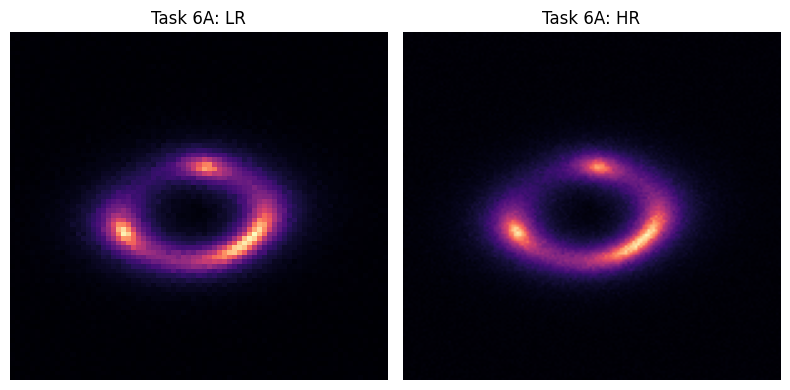

Pre-loading train dataset into RAM... Done!
Pre-loading val dataset into RAM... Done!

--- Running Task 6A | SRResNet | 2x Upscale ---
Epoch 01 | Train Loss (MSE): 0.00051 | Val MSE: 0.00030 | PSNR: 35.26 | SSIM: 0.9457
Epoch 02 | Train Loss (MSE): 0.00020 | Val MSE: 0.00016 | PSNR: 37.94 | SSIM: 0.9357
Epoch 03 | Train Loss (MSE): 0.00017 | Val MSE: 0.00011 | PSNR: 39.72 | SSIM: 0.9608
Epoch 04 | Train Loss (MSE): 0.00017 | Val MSE: 0.00009 | PSNR: 40.37 | SSIM: 0.9604
Epoch 05 | Train Loss (MSE): 0.00015 | Val MSE: 0.00011 | PSNR: 39.69 | SSIM: 0.9628
Epoch 06 | Train Loss (MSE): 0.00013 | Val MSE: 0.00009 | PSNR: 40.34 | SSIM: 0.9710
Epoch 07 | Train Loss (MSE): 0.00012 | Val MSE: 0.00008 | PSNR: 41.12 | SSIM: 0.9720
Epoch 08 | Train Loss (MSE): 0.00010 | Val MSE: 0.00008 | PSNR: 40.90 | SSIM: 0.9717
Epoch 09 | Train Loss (MSE): 0.00009 | Val MSE: 0.00008 | PSNR: 41.10 | SSIM: 0.9711
Epoch 10 | Train Loss (MSE): 0.00008 | Val MSE: 0.00008 | PSNR: 41.16 | SSIM: 0.9732
Saved best weig

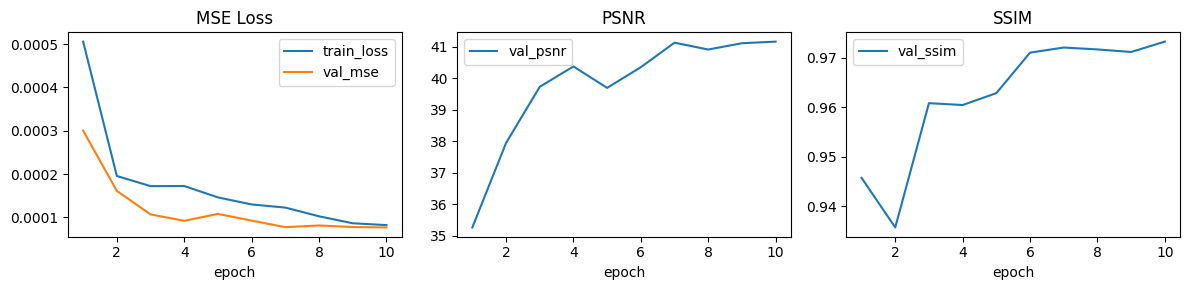

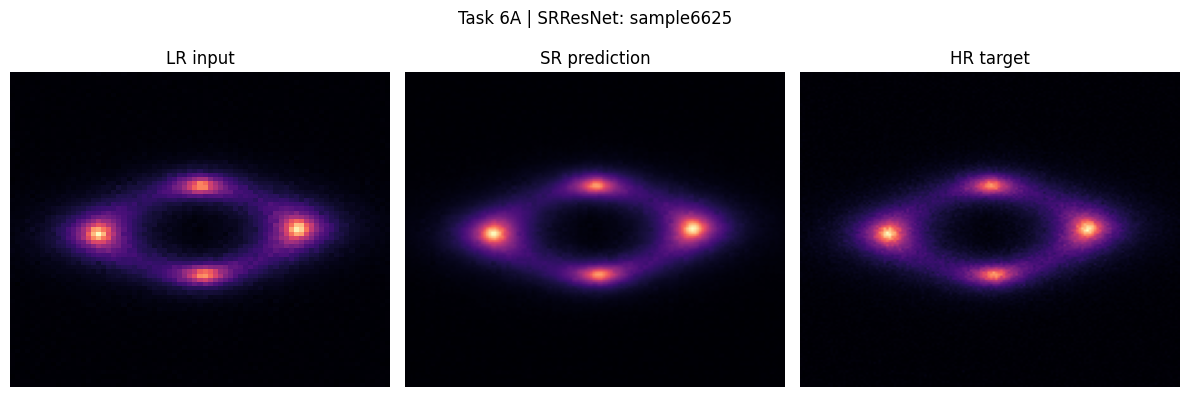

Pre-loading train dataset into RAM... Done!
Pre-loading val dataset into RAM... Done!

--- Running Task 6A | RCAN | 2x Upscale ---
Epoch 01 | Train Loss (MSE): 0.00017 | Val MSE: 0.00007 | PSNR: 41.30 | SSIM: 0.9714
Epoch 02 | Train Loss (MSE): 0.00008 | Val MSE: 0.00007 | PSNR: 41.45 | SSIM: 0.9709
Epoch 03 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.46 | SSIM: 0.9730
Epoch 04 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.61 | SSIM: 0.9739
Epoch 05 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.56 | SSIM: 0.9723
Epoch 06 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.61 | SSIM: 0.9734
Epoch 07 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.28 | SSIM: 0.9666
Epoch 08 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.51 | SSIM: 0.9732
Epoch 09 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.55 | SSIM: 0.9728
Epoch 10 | Train Loss (MSE): 0.00007 | Val MSE: 0.00008 | PSNR: 41.21 | SSIM: 0.9739
Saved best weights 

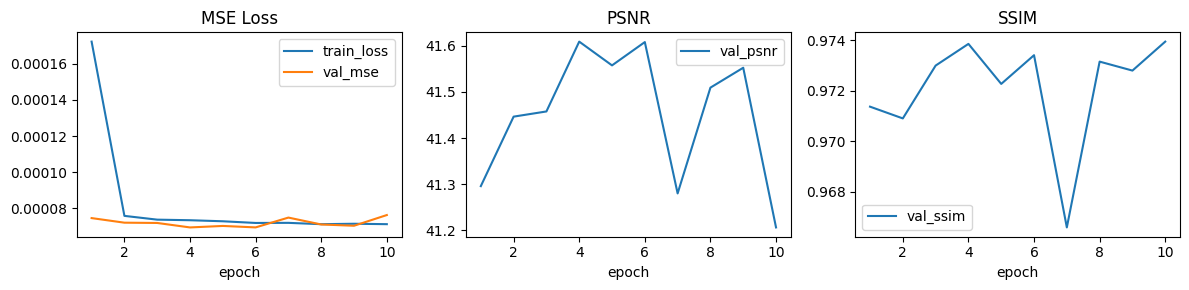

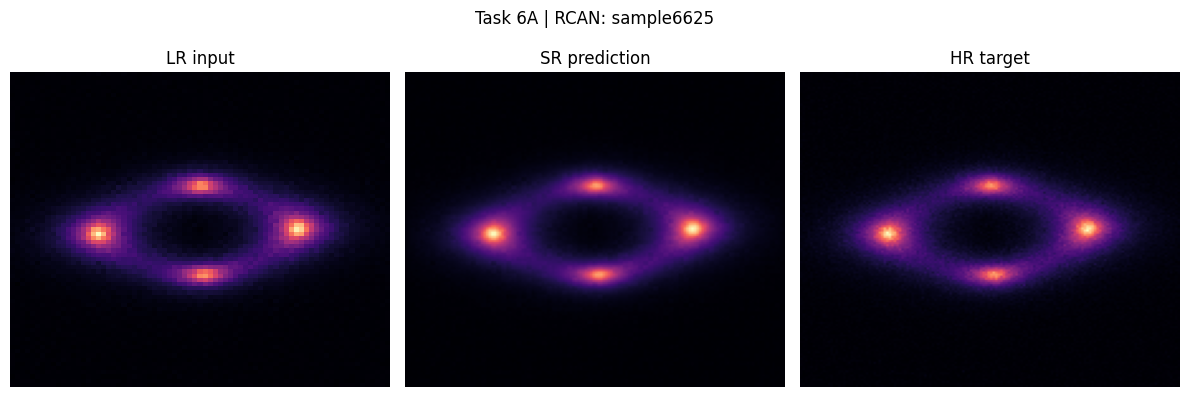

Pre-loading train dataset into RAM... Done!
Pre-loading val dataset into RAM... Done!

--- Running Task 6A | SwinIR | 2x Upscale ---
Epoch 01 | Train Loss (MSE): 0.00014 | Val MSE: 0.00008 | PSNR: 41.24 | SSIM: 0.9712
Epoch 02 | Train Loss (MSE): 0.00009 | Val MSE: 0.00009 | PSNR: 40.52 | SSIM: 0.9623
Epoch 03 | Train Loss (MSE): 0.00008 | Val MSE: 0.00014 | PSNR: 38.70 | SSIM: 0.9683
Epoch 04 | Train Loss (MSE): 0.00008 | Val MSE: 0.00007 | PSNR: 41.50 | SSIM: 0.9738
Epoch 05 | Train Loss (MSE): 0.00008 | Val MSE: 0.00008 | PSNR: 41.01 | SSIM: 0.9722
Epoch 06 | Train Loss (MSE): 0.00008 | Val MSE: 0.00007 | PSNR: 41.54 | SSIM: 0.9730
Epoch 07 | Train Loss (MSE): 0.00008 | Val MSE: 0.00007 | PSNR: 41.50 | SSIM: 0.9725
Epoch 08 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.43 | SSIM: 0.9729
Epoch 09 | Train Loss (MSE): 0.00007 | Val MSE: 0.00007 | PSNR: 41.60 | SSIM: 0.9742
Epoch 10 | Train Loss (MSE): 0.00007 | Val MSE: 0.00008 | PSNR: 41.14 | SSIM: 0.9736
Saved best weight

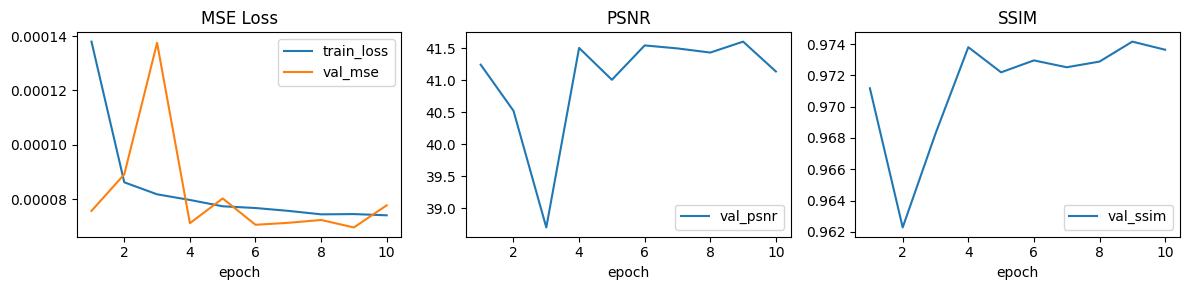

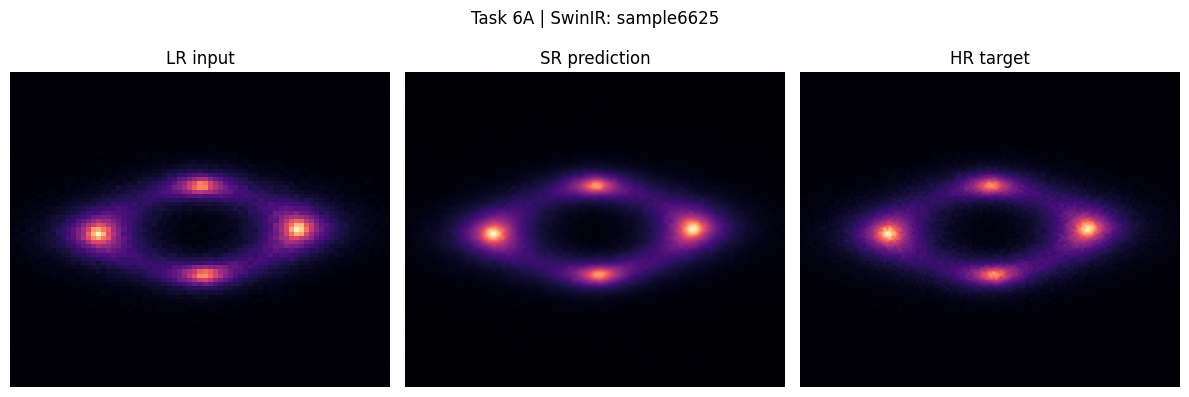


=== Task VI.A Model Comparison ===


,Model,val_mse,val_psnr,val_ssim
0,RCAN,0.000069,41.608598,0.973858
1,SwinIR,0.000070,41.602509,0.974155
2,SRResNet,0.000077,41.155428,0.973237


Task6B: found 300 paired samples
Samples: 300
Pre-loading eval dataset into RAM... Done!
Pair: 1
LR shape: (1, 64, 64) HR shape: (1, 128, 128)


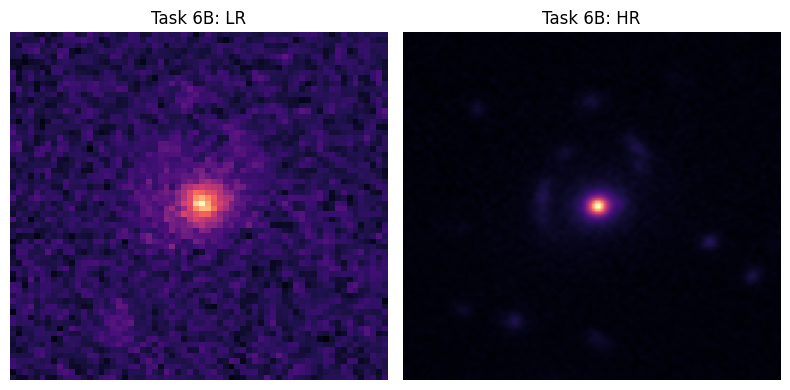

Pre-loading train dataset into RAM... Done!
Pre-loading val dataset into RAM... Done!

--- Running Task 6B | SRResNet | 2x Upscale ---
Epoch 01 | Train Loss (MSE): 0.00412 | Val MSE: 0.00149 | PSNR: 28.29 | SSIM: 0.5347
Epoch 02 | Train Loss (MSE): 0.00165 | Val MSE: 0.00095 | PSNR: 30.66 | SSIM: 0.7439
Epoch 03 | Train Loss (MSE): 0.00146 | Val MSE: 0.00085 | PSNR: 31.05 | SSIM: 0.7795
Epoch 04 | Train Loss (MSE): 0.00141 | Val MSE: 0.00083 | PSNR: 31.19 | SSIM: 0.8118
Epoch 05 | Train Loss (MSE): 0.00139 | Val MSE: 0.00088 | PSNR: 31.08 | SSIM: 0.7842
Saved best weights for Task 6B


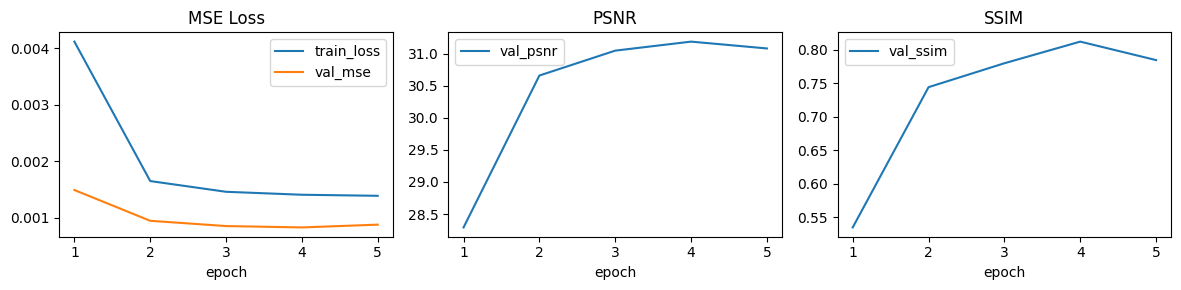

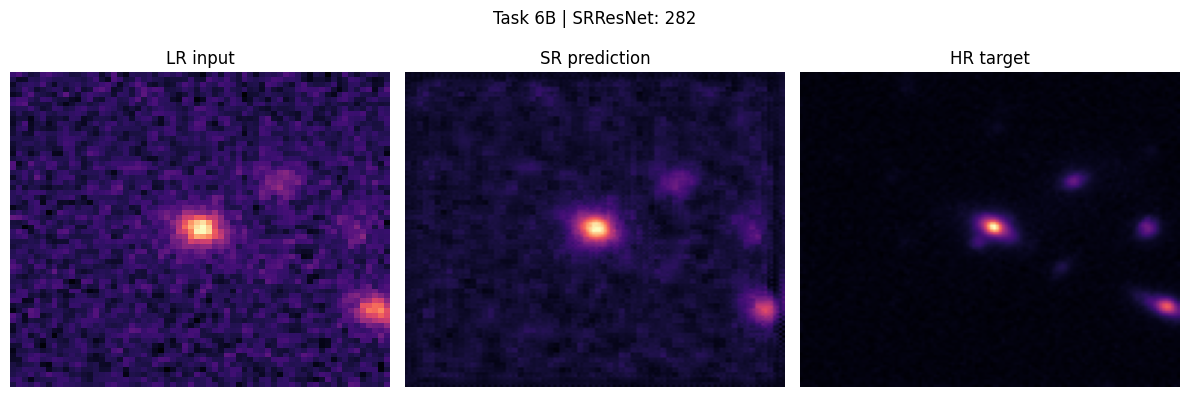

Pre-loading train dataset into RAM... Done!
Pre-loading val dataset into RAM... Done!

--- Running Task 6B | RCAN | 2x Upscale ---
Epoch 01 | Train Loss (MSE): 0.00502 | Val MSE: 0.00178 | PSNR: 27.76 | SSIM: 0.6591
Epoch 02 | Train Loss (MSE): 0.00241 | Val MSE: 0.00115 | PSNR: 29.92 | SSIM: 0.6696
Epoch 03 | Train Loss (MSE): 0.00182 | Val MSE: 0.00098 | PSNR: 30.40 | SSIM: 0.7187
Epoch 04 | Train Loss (MSE): 0.00163 | Val MSE: 0.00092 | PSNR: 30.70 | SSIM: 0.7792
Epoch 05 | Train Loss (MSE): 0.00157 | Val MSE: 0.00091 | PSNR: 30.73 | SSIM: 0.7894
Saved best weights for Task 6B


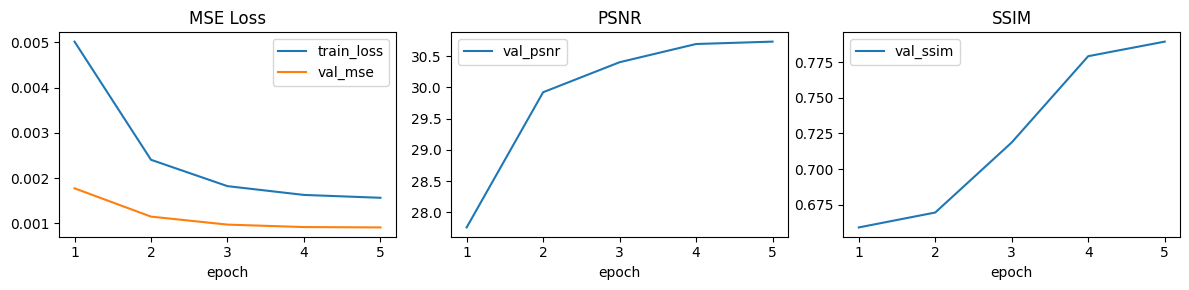

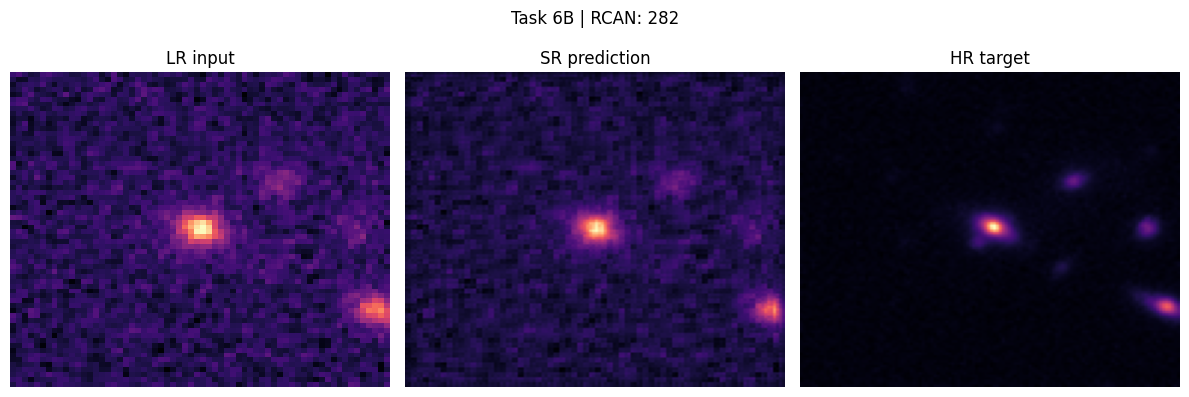

Pre-loading train dataset into RAM... Done!
Pre-loading val dataset into RAM... Done!

--- Running Task 6B | SwinIR | 2x Upscale ---
Epoch 01 | Train Loss (MSE): 0.00416 | Val MSE: 0.00092 | PSNR: 32.08 | SSIM: 0.7971
Epoch 02 | Train Loss (MSE): 0.00160 | Val MSE: 0.00080 | PSNR: 32.38 | SSIM: 0.8353
Epoch 03 | Train Loss (MSE): 0.00147 | Val MSE: 0.00081 | PSNR: 32.30 | SSIM: 0.8330
Epoch 04 | Train Loss (MSE): 0.00144 | Val MSE: 0.00080 | PSNR: 32.27 | SSIM: 0.8349
Epoch 05 | Train Loss (MSE): 0.00143 | Val MSE: 0.00080 | PSNR: 32.26 | SSIM: 0.8476
Saved best weights for Task 6B


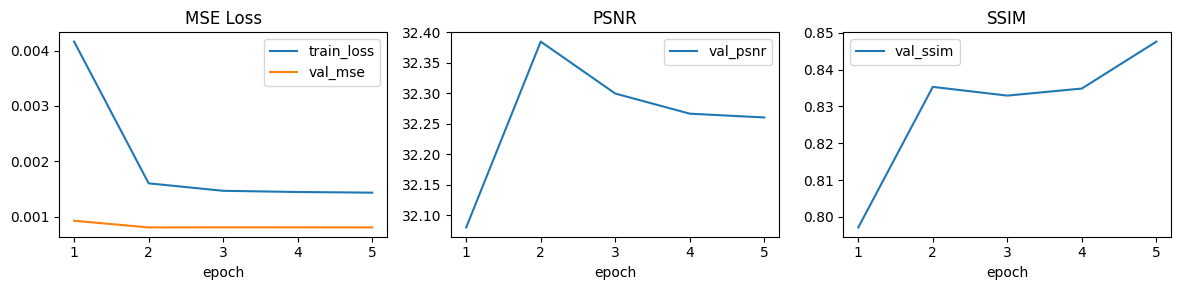

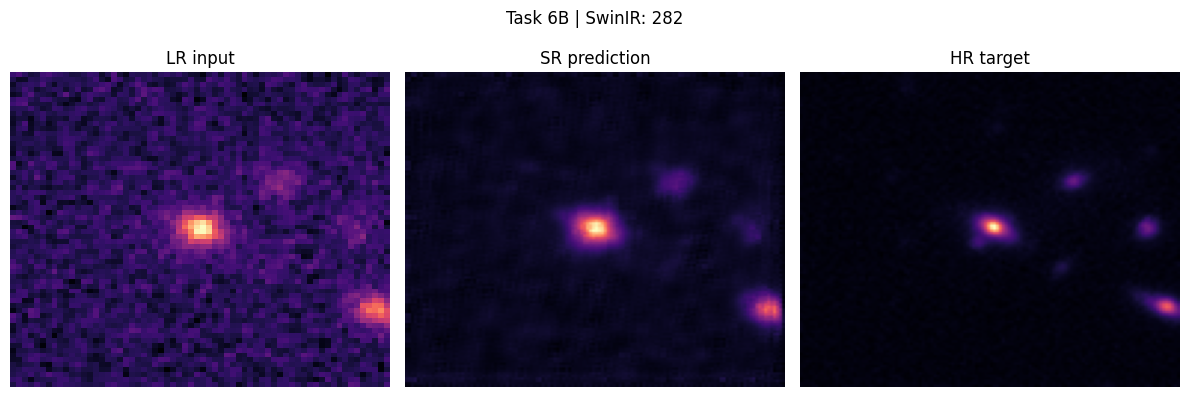


=== Task VI.B Domain Adaptation Comparison ===


,Model,val_mse,val_psnr,val_ssim
0,SwinIR,0.000803,32.384987,0.835323
1,SRResNet,0.000828,31.186954,0.811753
2,RCAN,0.000913,30.733136,0.789389


In [19]:
if __name__ == "__main__":
    # ==========================================
    # TASK VI.A: Supervised Training on Simulated Data
    # ==========================================
    records_a = collect_records(CFG.dataset_a_dir, "Task6A")
    preview_dataset(records_a, "Task 6A")

    results_a = {}
    best_states_a = {}

    for model_key, settings in experiment_settings.items():
        history, metrics, state, sample = run_experiment(records_a, model_key, "Task 6A", CFG.epochs_a)
        results_a[settings["display_name"]] = metrics
        best_states_a[model_key] = state
        show_reconstruction(sample, title=f"Task 6A | {settings['display_name']}")

    comp_a = pd.DataFrame.from_dict(results_a, orient="index").reset_index().rename(columns={"index": "Model"})
    print("\n=== Task VI.A Model Comparison ===")
    display(comp_a.sort_values("val_psnr", ascending=False).reset_index(drop=True))

    # ==========================================
    # TASK VI.B: Domain Adaptation on Real Telescope Data
    # ==========================================
    if CFG.use_dataset_b_finetune and CFG.dataset_b_dir.exists():
        records_b = collect_records(CFG.dataset_b_dir, "Task6B")
        preview_dataset(records_b, "Task 6B")

        if records_b.empty:
            print("\nTask VI.B was enabled, but no matched LR/HR pairs were found. Skipping fine-tuning.")
        else:
            results_b = {}

            for model_key, settings in experiment_settings.items():
                finetune_lr = settings["lr"] * 0.1
                history, metrics, state, sample = run_experiment(
                    records_b,
                    model_key,
                    "Task 6B",
                    CFG.epochs_b,
                    initial_state=best_states_a[model_key],
                    lr_override=finetune_lr,
                )
                results_b[settings["display_name"]] = metrics
                show_reconstruction(sample, title=f"Task 6B | {settings['display_name']}")

            comp_b = pd.DataFrame.from_dict(results_b, orient="index").reset_index().rename(columns={"index": "Model"})
            print("\n=== Task VI.B Domain Adaptation Comparison ===")
            display(comp_b.sort_values("val_psnr", ascending=False).reset_index(drop=True))